# ATELIER PRATIQUE EN IA II - 8INF974

Olivier BRIAND BRIO15040200

Aurélien CASAGRANDI CASA28100300

Grégory JOURDAIN JOUG28040300

## Test de l'agent DQN avec un CNN simple

Voici le code entier pour faire fonctionner un agent DQN sur le jeu Boxing d'Atari avec un CNN relativement simple. L'analyse des résultats se trouve dans le rapport.

In [1]:
import gymnasium as gym
import ale_py
import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
from collections import deque
import matplotlib.pyplot as plt


gym.register_envs(ale_py)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- Entraînement sur : {device} ---")

class AtariDQN(nn.Module):
    def __init__(self, n_actions):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(4, 64, 8, stride=4),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2),
            nn.ReLU(),
            nn.Conv2d(128, 256, 3, stride=1),
            nn.ReLU()
        )
        self.fc = nn.Sequential(
            nn.Linear(7 * 7 * 256, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

env = gym.make("ALE/Boxing-v5", obs_type="grayscale", frameskip=4)
env = gym.wrappers.ResizeObservation(env, (84, 84)) # Réduit l'image pour accélérer les calculs
env = gym.wrappers.FrameStackObservation(env, 4) # Empile 4 images pour percevoir le mouvement

n_actions = env.action_space.n
policy_net = AtariDQN(n_actions).to(device) # Réseau principal qui choisit les actions
target_net = AtariDQN(n_actions).to(device) # Réseau de référence pour stabiliser l'apprentissage
target_net.load_state_dict(policy_net.state_dict()) # Initialise le réseau cible à l'identique

optimizer = optim.Adam(policy_net.parameters(), lr=1e-4)
memory = deque(maxlen=30000) # Mémoire tampon (Replay Buffer) pour stocker les souvenirs du modèle

# Paramètres de lissage
batch_size = 64
gamma = 0.99       # Facteur d'escompte : définit l'importance des récompenses futures (0.99 = vision à long terme)
tau = 0.005        # Vitesse du soft update
steps = 0
eps_start = 1.0
eps_end = 0.02
eps_decay = 250000

# Listes pour les graphiques
all_scores = []
all_losses = []
all_epsilons = []


for episode in range(500):
    state, _ = env.reset()
    state = torch.tensor(np.array(state), dtype=torch.float32, device=device) / 255.0
    state = state.unsqueeze(0) # Forme [1, 4, 84, 84]
    
    total_reward = 0
    
    for t in range(10000):
        # Epsilon-Greedy
        epsilon = max(eps_end, eps_start - steps / eps_decay)
        steps += 1

        if random.random() < epsilon: # Exploration
            action = env.action_space.sample()
        else: # Exploitation
            with torch.no_grad():
                action = policy_net(state).argmax().item()

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward

        next_state_t = torch.tensor(np.array(next_state), dtype=torch.float32, device=device) / 255.0
        next_state_t = next_state_t.unsqueeze(0)

        # Stockage (CPU pour économiser la VRAM)
        memory.append((state.cpu(), action, reward, next_state_t.cpu(), done))
        state = next_state_t

       
        if len(memory) > 5000:
            batch = random.sample(memory, batch_size)
            b_states, b_actions, b_rewards, b_next_states, b_dones = zip(*batch)

            b_states = torch.cat(b_states).to(device)
            b_next_states = torch.cat(b_next_states).to(device)
            b_actions = torch.tensor(b_actions, device=device).unsqueeze(1)
            b_rewards = torch.tensor(b_rewards, device=device)
            b_dones = torch.tensor(b_dones, dtype=torch.float32, device=device)

            # Calcul de Q
            current_q = policy_net(b_states).gather(1, b_actions).squeeze()
            
            with torch.no_grad():
                max_next_q = target_net(b_next_states).max(1)[0] # Meilleur score futur estimé
                target_q = b_rewards + (gamma * max_next_q * (1 - b_dones)) # Valeur cible idéale (Récompense + Futur)

            loss = nn.MSELoss()(current_q, target_q)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            all_losses.append(loss.item())

            # Soft update (Lissage du Target Net)
            with torch.no_grad():
                for target_param, policy_param in zip(target_net.parameters(), policy_net.parameters()):
                    # Fusion lente des réseaux pour stabiliser l'apprentissage
                    target_param.data.copy_(tau * policy_param.data + (1.0 - tau) * target_param.data)

        if done:
            break
            
    all_scores.append(total_reward)
    all_epsilons.append(epsilon)
    
    if episode % 10 == 0:
        avg_score = np.mean(all_scores[-10:])
        print(f"Épisode {episode:3} | Score: {total_reward:3.0f} | Moyenne (10): {avg_score:3.1f} | Eps: {epsilon:.2f}")

    if episode % 100 == 0:
        torch.save(policy_net.state_dict(), f"boxing_dqn_{episode}.pth")

env.close()

--- Entraînement sur : cuda ---


A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


Épisode   0 | Score:   8 | Moyenne (10): 8.0 | Eps: 0.99
Épisode  10 | Score:   4 | Moyenne (10): -1.2 | Eps: 0.92
Épisode  20 | Score:  -1 | Moyenne (10): -0.4 | Eps: 0.85
Épisode  30 | Score:   8 | Moyenne (10): 1.0 | Eps: 0.78
Épisode  40 | Score:   5 | Moyenne (10): 0.9 | Eps: 0.71
Épisode  50 | Score:  23 | Moyenne (10): 7.3 | Eps: 0.64
Épisode  60 | Score:   2 | Moyenne (10): 3.9 | Eps: 0.56
Épisode  70 | Score:   0 | Moyenne (10): 0.3 | Eps: 0.49
Épisode  80 | Score:  -7 | Moyenne (10): -3.1 | Eps: 0.42
Épisode  90 | Score:  -4 | Moyenne (10): -1.2 | Eps: 0.35
Épisode 100 | Score: -12 | Moyenne (10): -6.4 | Eps: 0.28
Épisode 110 | Score:  -3 | Moyenne (10): 0.9 | Eps: 0.21
Épisode 120 | Score:   1 | Moyenne (10): -1.9 | Eps: 0.14
Épisode 130 | Score:   0 | Moyenne (10): -3.2 | Eps: 0.06
Épisode 140 | Score:  -2 | Moyenne (10): -1.8 | Eps: 0.02
Épisode 150 | Score:   1 | Moyenne (10): -7.0 | Eps: 0.02
Épisode 160 | Score: -11 | Moyenne (10): -4.4 | Eps: 0.02
Épisode 170 | Score: 

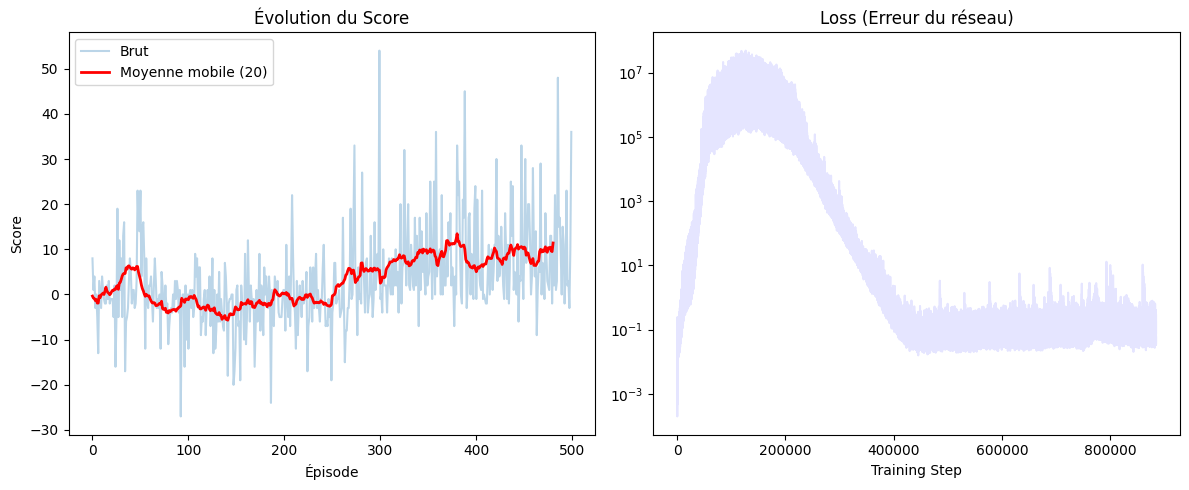

In [2]:
def plot_results(scores, losses):
    plt.figure(figsize=(12, 5))
    
    # Graphique des scores
    plt.subplot(1, 2, 1)
    plt.plot(scores, alpha=0.3, label="Brut")
    if len(scores) >= 20:
        means = np.convolve(scores, np.ones(20)/20, mode='valid')
        plt.plot(means, label="Moyenne mobile (20)", color='red', linewidth=2)
    plt.title("Évolution du Score")
    plt.xlabel("Épisode")
    plt.ylabel("Score")
    plt.legend()

    # Graphique de la Loss (moyenne par épisode pour lisibilité)
    plt.subplot(1, 2, 2)
    plt.plot(losses, color='blue', alpha=0.1)
    plt.title("Loss (Erreur du réseau)")
    plt.yscale('log') # Log scale car la loss varie beaucoup
    plt.xlabel("Training Step")
    
    plt.tight_layout()
    plt.show()
plot_results(all_scores, all_losses)

## Test de l'agent DQN avec un transformer

Voici le code entier pour faire fonctionner un agent DQN sur le jeu Boxing d'Atari avec un transformer. L'analyse des résultats se trouve dans le rapport.

In [1]:
import gymnasium as gym
import ale_py
import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
from tqdm import tqdm

gym.register_envs(ale_py)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- Entraînement sur : {device} ---")

class AtariDQN(nn.Module):
    def __init__(self, n_actions, dim=256, depth=4, heads=8, patch_size=7):
        super().__init__()

        #Découper les images en patches
        self.patch_size = patch_size
        self.dim = dim
        self.to_patch_embedding = nn.Sequential(
            nn.Conv2d(4, dim, kernel_size=patch_size, stride=patch_size),  # [batch, dim, 12, 12] si 84/7=12
            nn.Flatten(2),  # flatten H*W → tokens
            # nn.Transpose(-1, -2) # [batch, num_tokens, dim]
        )

        #Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(d_model=dim, nhead=heads)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        #Head pour Q-values
        self.mlp = nn.Sequential(
            nn.Linear(dim * (12*12), 512),
            nn.ReLU(),
            nn.Linear(512, n_actions)
        )

    def forward(self, x):
        # Patch embedding
        x = self.to_patch_embedding(x)  # [batch, num_tokens, dim]
        x = x.transpose(1, 2)            # [batch, num_tokens, dim]
        # Transformer
        x = self.transformer(x)         # [batch, num_tokens, dim]
        # Flatten tokens
        x = x.flatten(1)                # [batch, num_tokens*dim]

        # Head
        return self.mlp(x)

env = gym.make("ALE/Boxing-v5", obs_type="grayscale", frameskip=4)
env = gym.wrappers.ResizeObservation(env, (84, 84)) # Réduit l'image pour accélérer les calculs
env = gym.wrappers.FrameStackObservation(env, 4) # Empile 4 images pour percevoir le mouvement

n_actions = env.action_space.n
policy_net = AtariDQN(n_actions).to(device) # Réseau principal qui choisit les actions
target_net = AtariDQN(n_actions).to(device) # Réseau de référence pour stabiliser l'apprentissage
target_net.load_state_dict(policy_net.state_dict()) # Initialise le réseau cible à l'identique

optimizer = optim.Adam(policy_net.parameters(), lr=1e-4)
memory = deque(maxlen=30000) # Mémoire tampon (Replay Buffer) pour stocker les souvenirs du modèle

# Paramètres de lissage
batch_size = 64
gamma = 0.99       # Facteur d'escompte : définit l'importance des récompenses futures (0.99 = vision à long terme)
tau = 0.005        # Vitesse du soft update
steps = 0
eps_start = 1.0
eps_end = 0.02
eps_decay = 250000

# Listes pour les graphiques
all_scores = []
all_losses = []
all_epsilons = []


for episode in range(500):
    state, _ = env.reset()
    state = torch.tensor(np.array(state), dtype=torch.float32, device=device) / 255.0
    state = state.unsqueeze(0) # Forme [1, 4, 84, 84]

    total_reward = 0

    for t in range(10000):
        # Epsilon-Greedy
        epsilon = max(eps_end, eps_start - steps / eps_decay)
        steps += 1

        if random.random() < epsilon: # Exploration
            action = env.action_space.sample()
        else: # Exploitation
            with torch.no_grad():
                action = policy_net(state).argmax().item()

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward

        next_state_t = torch.tensor(np.array(next_state), dtype=torch.float32, device=device) / 255.0
        next_state_t = next_state_t.unsqueeze(0)

        # Stockage (CPU pour économiser la VRAM)
        memory.append((state.cpu(), action, reward, next_state_t.cpu(), done))
        state = next_state_t


        if len(memory) > 5000:
            batch = random.sample(memory, batch_size)
            b_states, b_actions, b_rewards, b_next_states, b_dones = zip(*batch)

            b_states = torch.cat(b_states).to(device)
            b_next_states = torch.cat(b_next_states).to(device)
            b_actions = torch.tensor(b_actions, device=device).unsqueeze(1)
            b_rewards = torch.tensor(b_rewards, device=device)
            b_dones = torch.tensor(b_dones, dtype=torch.float32, device=device)

            # Calcul de Q
            current_q = policy_net(b_states).gather(1, b_actions).squeeze()

            with torch.no_grad():
                max_next_q = target_net(b_next_states).max(1)[0] # Meilleur score futur estimé
                target_q = b_rewards + (gamma * max_next_q * (1 - b_dones)) # Valeur cible idéale (Récompense + Futur)

            loss = nn.MSELoss()(current_q, target_q)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            all_losses.append(loss.item())

            # Soft update (Lissage du Target Net)
            with torch.no_grad():
                for target_param, policy_param in zip(target_net.parameters(), policy_net.parameters()):
                    # Fusion lente des réseaux pour stabiliser l'apprentissage
                    target_param.data.copy_(tau * policy_param.data + (1.0 - tau) * target_param.data)

        if done:
            break

    all_scores.append(total_reward)
    all_epsilons.append(epsilon)

    if episode % 10 == 0:
        avg_score = np.mean(all_scores[-10:])
        print(f"Épisode {episode:3} | Score: {total_reward:3.0f} | Moyenne (10): {avg_score:3.1f} | Eps: {epsilon:.2f}")

    if episode % 25 == 0:
        torch.save(policy_net.state_dict(), f"boxing_dqn_{episode}.pth")

env.close()

--- Entraînement sur : cuda ---


A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
/tmp/ipykernel_11986/2340051910.py:31: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)


Épisode   0 | Score:   3 | Moyenne (10): 3.0 | Eps: 0.99
Épisode  10 | Score:  10 | Moyenne (10): 1.3 | Eps: 0.92
Épisode  20 | Score:   1 | Moyenne (10): 0.5 | Eps: 0.85
Épisode  30 | Score:   4 | Moyenne (10): 0.6 | Eps: 0.78
Épisode  40 | Score:  -1 | Moyenne (10): 0.5 | Eps: 0.71
Épisode  50 | Score: -10 | Moyenne (10): -1.8 | Eps: 0.64
Épisode  60 | Score:  -4 | Moyenne (10): -2.3 | Eps: 0.56
Épisode  70 | Score:  -1 | Moyenne (10): -0.5 | Eps: 0.49
Épisode  80 | Score:   8 | Moyenne (10): -0.1 | Eps: 0.42
Épisode  90 | Score: -11 | Moyenne (10): -5.2 | Eps: 0.35
Épisode 100 | Score:   0 | Moyenne (10): -2.8 | Eps: 0.28
Épisode 110 | Score:  -6 | Moyenne (10): -6.1 | Eps: 0.21
Épisode 120 | Score: -22 | Moyenne (10): -12.8 | Eps: 0.14
Épisode 130 | Score: -39 | Moyenne (10): -28.7 | Eps: 0.06
Épisode 140 | Score: -40 | Moyenne (10): -34.1 | Eps: 0.02
Épisode 150 | Score: -38 | Moyenne (10): -29.2 | Eps: 0.02
Épisode 160 | Score: -26 | Moyenne (10): -39.0 | Eps: 0.02
Épisode 170 | 

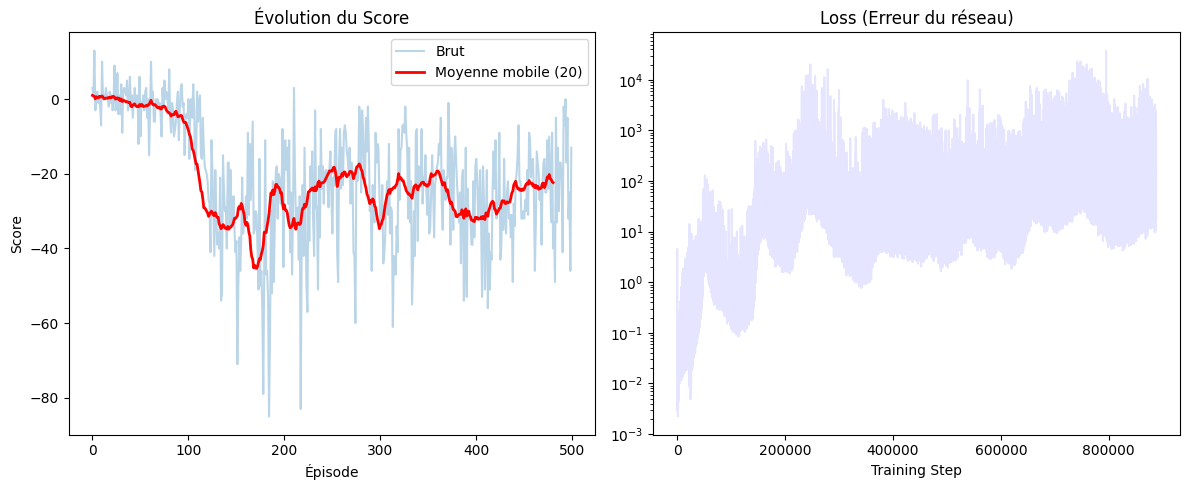

In [2]:


def plot_results(scores, losses):
    plt.figure(figsize=(12, 5))

    # Graphique des scores
    plt.subplot(1, 2, 1)
    plt.plot(scores, alpha=0.3, label="Brut")
    if len(scores) >= 20:
        means = np.convolve(scores, np.ones(20)/20, mode='valid')
        plt.plot(means, label="Moyenne mobile (20)", color='red', linewidth=2)
    plt.title("Évolution du Score")
    plt.xlabel("Épisode")
    plt.ylabel("Score")
    plt.legend()

    # Graphique de la Loss (moyenne par épisode pour lisibilité)
    plt.subplot(1, 2, 2)
    plt.plot(losses, color='blue', alpha=0.1)
    plt.title("Loss (Erreur du réseau)")
    plt.yscale('log') # Log scale car la loss varie beaucoup
    plt.xlabel("Training Step")

    plt.tight_layout()
    plt.show()

plot_results(all_scores, all_losses)

